# **PROJECT TITLE**

# **App User Behavior Segmentation Using Unsupervised Machine learning**

**Tools and Technologies Used :** Python | Pandas | NumPy | EDA | Matplotlib | Seaborn | Scikit-learn | Machine learning algorithm

**Developed By :** Mohana Selvi

## **Project Overview**

### This project focuses on analyzing mobile application user behavior and grouping users based on their activity patterns.

### By using Exploratory Data Analysis (EDA) and Unsupervised Machine Learning techniques, the project identifies meaningful patterns in user activity. 

### The K-Means clustering algorithm is applied to segment users into different groups.

### These user segments help businesses understand user engagement levels and improve marketing strategies and user experience.

## **Project Objectives**

### 1. To analyze app user behavior using data analysis techniques.

### 2. To perform Exploratory Data Analysis (EDA) to understand user activity patterns.

### 3. To apply K-Means clustering to segment users based on their behavior.

### 4. To visualize and interpret user clusters for better insights.

### 5. To help businesses improve user engagement and decision-making.

## **Project Workflow**
1. Data Collection
2. Data Understanding
3. Data Cleaning & Preprocessing
4. Feature Selection 
5. Data Scaling 
6. Clustering Model Selection
7. Optimal Cluster Identification 
8. Cluster Assignment 
9. Cluster-Level User Identification & Profiling
10. Business Insight Generation & Customer Action Mapping


# Step 1 : Data Collection

In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("app_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [4]:
# To display all the columns

pd.set_option('display.max_columns',None)
df.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,5,8,8,1,0,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,7,3,7,0,0,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,5,2,21,1,0,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,8,4,13,0,0,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,7,3,15,0,0,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


# Step 2 : Data Understanding

In [5]:
# Dataset Shape
print("Dataset Shape : ",df.shape)

Dataset Shape :  (50000, 25)


In [6]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [7]:
# Summary Statistics
df.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


In [8]:
# Missing Values
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

In [9]:
# To view column names
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='object')

# Step 3 : Data cleaning & Preprocessing

## 3.1 Check Missing Values

In [10]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

## 3.2 Handle Missing Values

In [12]:
df['rating_given']=df['rating_given'].fillna(df['rating_given'].median())

In [13]:
df.isnull().sum()

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64

## 3.3 Remove Unnecessary Columns

In [14]:
df=df.drop(columns=['user_id'])

## 3.4 Check Duplicate Rows

In [15]:
df.duplicated().sum()

np.int64(0)

## 3.5 Convert Categorial Columns

In [16]:
from sklearn .preprocessing import LabelEncoder

In [17]:
le=LabelEncoder()
categorical_cols=['gender','country','device_type','subscription_type','marketing_source']
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

## 3.6 Verify Clean Dataset

In [18]:
df.head()

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,56,0,3,2,2.1,5,3.41,52.71,13,5,8,8,1,0,20,0,9,5,2,4.0,0.31,55.79,1152,4
1,46,1,5,2,1.0,8,24.44,42.03,7,7,3,7,0,0,7,1,8,3,3,3.0,0.87,82.39,1059,0
2,32,0,5,2,1.2,12,5.34,76.69,7,5,2,21,1,0,33,1,11,6,1,2.0,0.63,42.49,678,2
3,25,1,3,0,2.0,5,3.98,65.38,16,8,4,13,0,0,17,0,6,3,1,3.0,0.43,62.81,92,3
4,38,1,0,0,1.0,10,12.85,57.06,13,7,3,15,0,0,21,0,4,4,2,5.0,0.43,38.21,772,0


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   gender                         50000 non-null  int64  
 2   country                        50000 non-null  int64  
 3   device_type                    50000 non-null  int64  
 4   app_version                    50000 non-null  float64
 5   sessions_per_week              50000 non-null  int64  
 6   avg_session_duration_min       50000 non-null  float64
 7   daily_active_minutes           50000 non-null  float64
 8   feature_clicks_per_session     50000 non-null  int64  
 9   notifications_opened_per_week  50000 non-null  int64  
 10  in_app_search_count            50000 non-null  int64  
 11  pages_viewed_per_session       50000 non-null  int64  
 12  crash_events_last_30_days      50000 non-null 

# Step 4 :  Feature Selection 

## 4.1 To Check All Columns

In [20]:
# display all columns
df.columns

Index(['age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='object')

## 4.2 Select Numerical Features for Clustering

In [21]:
features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'engagement_score'
]

X = df[features]

## 4.3 View Selected Dataset

In [23]:
X.head()

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,engagement_score
0,5,3.41,52.71,13,5,8,8,55.79
1,8,24.44,42.03,7,7,3,7,82.39
2,12,5.34,76.69,7,5,2,21,42.49
3,5,3.98,65.38,16,8,4,13,62.81
4,10,12.85,57.06,13,7,3,15,38.21


## 4.4 Check Shape of Selected Data

In [24]:
X.shape

(50000, 8)

# Step 5 : Data Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [33]:
# Convert sacled data into dataframe
X_scaled=pd.DataFrame(X_scaled,columns=X.columns)

In [34]:
# To view the scaled dataset
X_scaled.head()

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,engagement_score
0,-1.060179,-1.088633,0.386849,0.283336,0.001512,2.002730,-0.862410,-0.616659
1,0.000113,1.261914,-0.160705,-1.440677,0.896304,-0.500094,-1.020050,1.175953
2,1.413835,-0.872915,1.616282,-1.440677,0.001512,-1.000659,1.186909,-1.512965
3,-1.060179,-1.024924,1.036429,1.145342,1.343700,0.000471,-0.074211,-0.143571
4,0.706974,-0.033514,0.609870,0.283336,0.896304,-0.500094,0.241069,-1.801401


In [35]:
# To check shape
X_scaled.shape

(50000, 8)

# Step 6 : Clustering Model Selection

In [36]:
from sklearn.cluster import KMeans

In [37]:
# To determine optimal clusters ( Elbow Method )
import matplotlib.pyplot as plt

inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

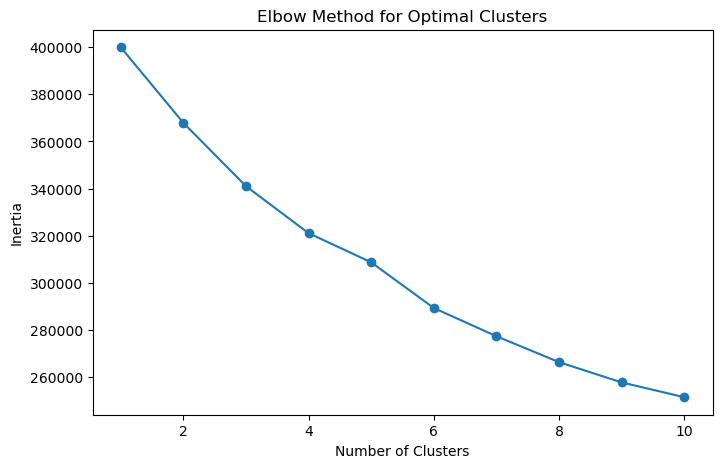

In [38]:
# To plot the Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [39]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [40]:
# Add cluster lables to Dataset
df['Cluster']=clusters

In [41]:
df.head()

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,Cluster
0,56,0,3,2,2.1,5,3.41,52.71,13,5,8,8,1,0,20,0,9,5,2,4.0,0.31,55.79,1152,4,3
1,46,1,5,2,1.0,8,24.44,42.03,7,7,3,7,0,0,7,1,8,3,3,3.0,0.87,82.39,1059,0,1
2,32,0,5,2,1.2,12,5.34,76.69,7,5,2,21,1,0,33,1,11,6,1,2.0,0.63,42.49,678,2,2
3,25,1,3,0,2.0,5,3.98,65.38,16,8,4,13,0,0,17,0,6,3,1,3.0,0.43,62.81,92,3,0
4,38,1,0,0,1.0,10,12.85,57.06,13,7,3,15,0,0,21,0,4,4,2,5.0,0.43,38.21,772,0,0


# Step 7 : Optimal Cluster Identification 

In [43]:
from sklearn.cluster import KMeans

In [44]:
# To calculate Inertia Values
inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

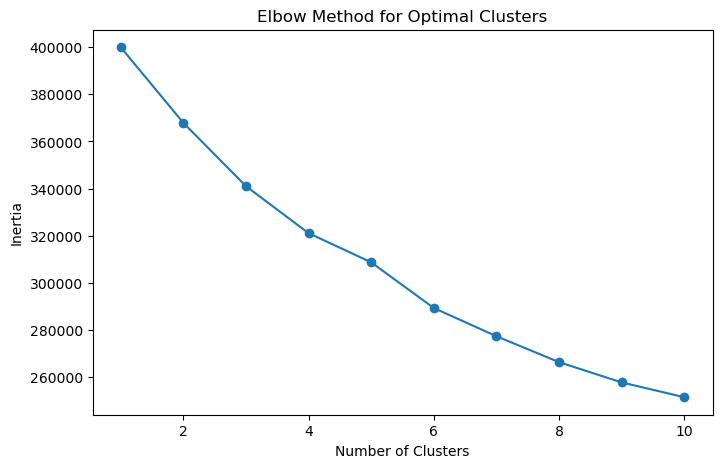

In [45]:
# Plot the Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Step 8 : Cluster Assignment 

## 8.1 Train the K-Means Model

In [46]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

## 8.2 Predict Cluster Lables

In [47]:
clusters = kmeans.predict(X_scaled)

In [48]:
clusters[:10]

array([3, 1, 2, 0, 0, 2, 1, 0, 1, 1], dtype=int32)

## 8.3 Add Cluster Column to Dataset

In [49]:
df['Cluster'] = clusters

## 8.4 View Clustered Dataset

In [50]:
df.head()

,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source,Cluster
0,56,0,3,2,2.1,5,3.41,52.71,13,5,8,8,1,0,20,0,9,5,2,4.0,0.31,55.79,1152,4,3
1,46,1,5,2,1.0,8,24.44,42.03,7,7,3,7,0,0,7,1,8,3,3,3.0,0.87,82.39,1059,0,1
2,32,0,5,2,1.2,12,5.34,76.69,7,5,2,21,1,0,33,1,11,6,1,2.0,0.63,42.49,678,2,2
3,25,1,3,0,2.0,5,3.98,65.38,16,8,4,13,0,0,17,0,6,3,1,3.0,0.43,62.81,92,3,0
4,38,1,0,0,1.0,10,12.85,57.06,13,7,3,15,0,0,21,0,4,4,2,5.0,0.43,38.21,772,0,0


## 8.5 Check Cluster Distribution

In [51]:
df['Cluster'].value_counts()

Cluster
3    16857
2    12989
0    12351
1     7803
Name: count, dtype: int64

## 8.6 PCA Visualization

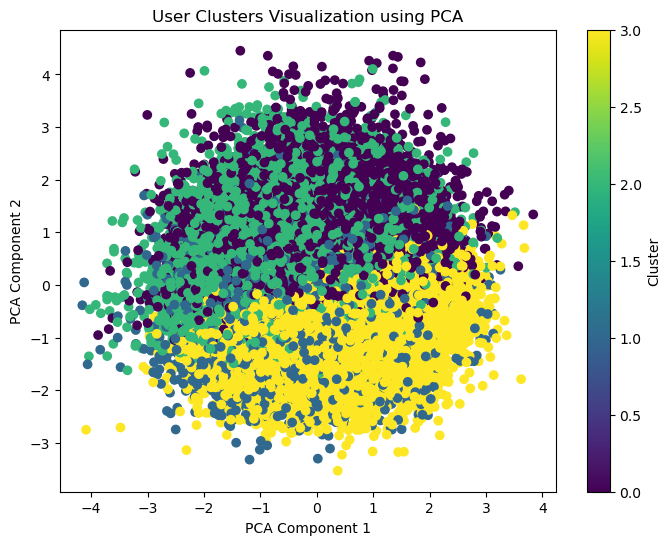

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dataset to 2 dimensions
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_components[:,0], pca_components[:,1], c=df['Cluster'], cmap='viridis')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("User Clusters Visualization using PCA")

plt.colorbar(label="Cluster")
plt.show()

# Step 9 : Cluster-Level User Identification & Profiling 

## 9.1 Count Users in Each Cluster

In [52]:
df['Cluster'].value_counts()

Cluster
3    16857
2    12989
0    12351
1     7803
Name: count, dtype: int64

## 9.2 Calculate Average Behavior per Cluster

In [53]:
cluster_profile = df.groupby('Cluster')[[
'sessions_per_week',
'avg_session_duration_min',
'daily_active_minutes',
'feature_clicks_per_session',
'notifications_opened_per_week',
'in_app_search_count',
'pages_viewed_per_session',
'engagement_score'
]].mean()

cluster_profile

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,engagement_score
Cluster,,,,,,,,
0,7.345316,10.605659,42.980151,12.182819,7.650878,4.133430,13.064934,63.566040
1,7.753044,28.741440,44.923623,11.989363,4.749071,3.954889,13.645649,64.477650
2,11.138964,10.583986,43.298386,11.680730,4.335823,4.280699,13.149742,63.247512
3,6.174349,9.773788,48.314483,12.158273,3.675624,3.704040,13.934508,67.466052


## 9.3 Visualize Cluster Size

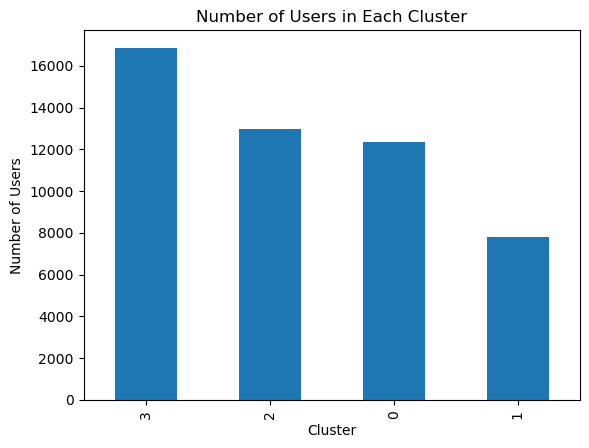

In [54]:
import matplotlib.pyplot as plt

df['Cluster'].value_counts().plot(kind='bar')
plt.title("Number of Users in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.show()

## 9.4 Interpret Clusters

Cluster Profiling

Cluster 0 – Occasional Users  
Users with low engagement and fewer sessions.

Cluster 1 – Low Engagement Users  
Users who interact minimally with app features.

Cluster 2 – Moderate Users  
Users with moderate activity and consistent usage.

Cluster 3 – Highly Active Users  
Users with high engagement, frequent sessions, and strong interaction with app features.

# Step 10 : Business Insight Generation & Customer Action Mapping

### In this step, the identified user clusters are translated into actionable business insights. Each cluster is analyzed to understand user behavior and engagement levels. Based on these insights, targeted marketing and customer retention strategies can be developed.
 

## 10.1 Identify High-Value Customers

High-Value Customers ( Cluster 3 )

These users show high engagement with the application. They have higher session frequency, longer session duration, and higher interaction with app features.

Business Action:
       These users should be targeted with loyalty rewards, premium subscriptions,
exclusive offers , and early access to new features to maintain their engagement.

## 10.2 Identify Low-Engagement or At-Risk Users

Low-Engagement Users ( Cluster 1 )

These users have lower session activity and minimal interaction with app features.

Business Action:
      Retention campaigns such as push notifications, reminder emails,
discount offers, and onboarding tutorials can help re-engage these users.

## 10.3 Moderate Users Engagement Strategies

Moderate Users ( Cluster 2 )

These users have moderate activity and engagement levels.

Business Action:
      Provide personalized recommendations, feature suggestions,
and targeted promotions to increase their engagement and convert
them into highly active users.

## 10.4 Supported marketing, product, and retention decisions

The clustering results help business teams make data-driven decisions.

Marketing teams can design targeted campaigns based on user engagement levels.
Product teams can improve features that highly engaged users interact with the most.
Retention teams can identify at-risk users and design strategies to prevent churn.

By understanding the behavior of each cluster, the company can allocate resources
more effectively and improve overall customer satisfaction.

## 10.5 Enable customer-level targeting instead of generic campaigns

Traditional marketing campaigns often treat all users the same.
However, customer segmentation allows businesses to target specific user groups
based on their behavior.

For example:
* Highly active users can receive loyalty rewards and premium offers.
* Moderate users can receive personalized recommendations to increase engagement.
* Low-engagement users can receive reactivation campaigns such as discounts or reminders.

This targeted approach improves marketing efficiency and increases customer retention
compared to generic campaigns applied to all users.